In [ ]:
# -------------------------------------------
# Step 1: Import Required Libraries
# -------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import fashion_mnist
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [ ]:
# -------------------------------------------
# Step 2: Load the Dataset
# -------------------------------------------
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


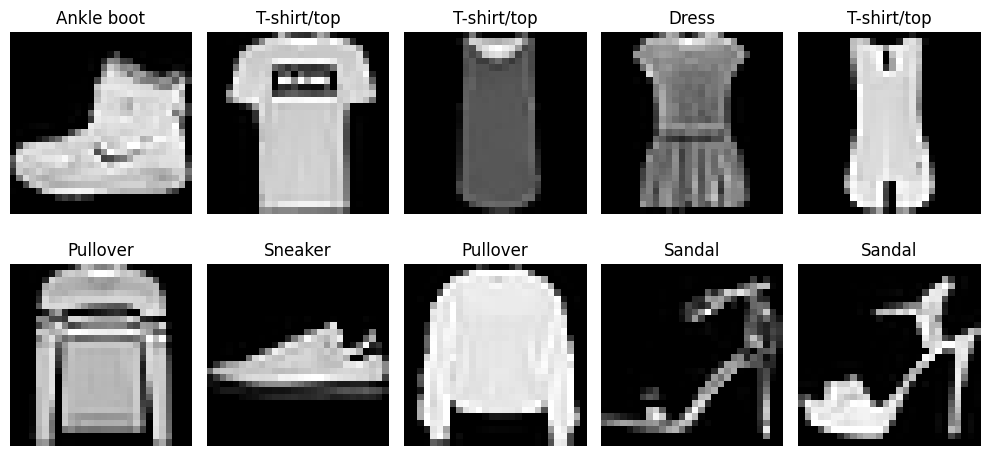

In [ ]:
# -------------------------------------------
# Step 3: Data Visualization
# -------------------------------------------
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:

# -------------------------------------------
# Step 4: Data Preprocessing
# -------------------------------------------
# Flatten 28x28 images into 1D array (784 features)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Scale data for better convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

print("After flattening:", X_train_scaled.shape)

After flattening: (60000, 784)


In [ ]:
# -------------------------------------------
# Step 5: Train Models
# -------------------------------------------

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)
log_acc = accuracy_score(y_test, log_pred)
print(f"Logistic Regression Accuracy: {log_acc:.4f}")

# Support Vector Machine
svm_model = SVC(kernel='rbf')
svm_model.fit(X_train_scaled[:10000], y_train[:10000])  # Using subset for faster training
svm_pred = svm_model.predict(X_test_scaled[:2000])
svm_acc = accuracy_score(y_test[:2000], svm_pred)
print(f"SVM Accuracy: {svm_acc:.4f}")

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train_scaled[:15000], y_train[:15000])
rf_pred = rf_model.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_acc:.4f}")

# K-Nearest Neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled[:10000], y_train[:10000])
knn_pred = knn_model.predict(X_test_scaled[:2000])
knn_acc = accuracy_score(y_test[:2000], knn_pred)
print(f"KNN Accuracy: {knn_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.8353
SVM Accuracy: 0.8560
Random Forest Accuracy: 0.8575
KNN Accuracy: 0.8180


/tmp/ipython-input-1124038441.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Algorithm", y="Accuracy", data=acc_df, palette="viridis")


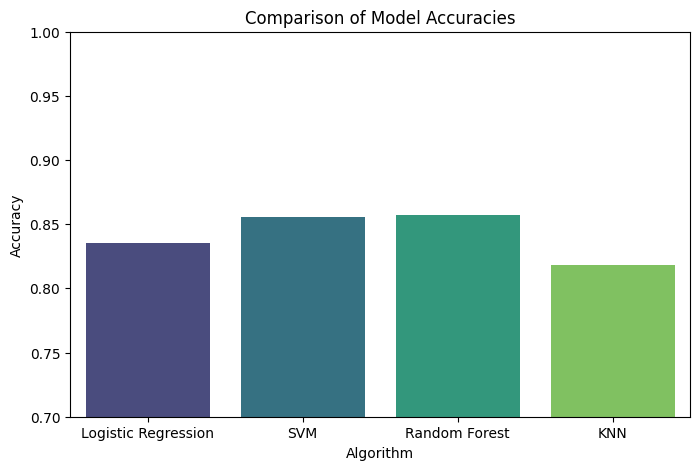

In [ ]:
# -------------------------------------------
# Step 6: Compare Model Accuracies
# -------------------------------------------
accuracy_data = {
    "Algorithm": ["Logistic Regression", "SVM", "Random Forest", "KNN"],
    "Accuracy": [log_acc, svm_acc, rf_acc, knn_acc]
}
acc_df = pd.DataFrame(accuracy_data)

plt.figure(figsize=(8,5))
sns.barplot(x="Algorithm", y="Accuracy", data=acc_df, palette="viridis")
plt.title("Comparison of Model Accuracies")
plt.ylim(0.7, 1)
plt.show()

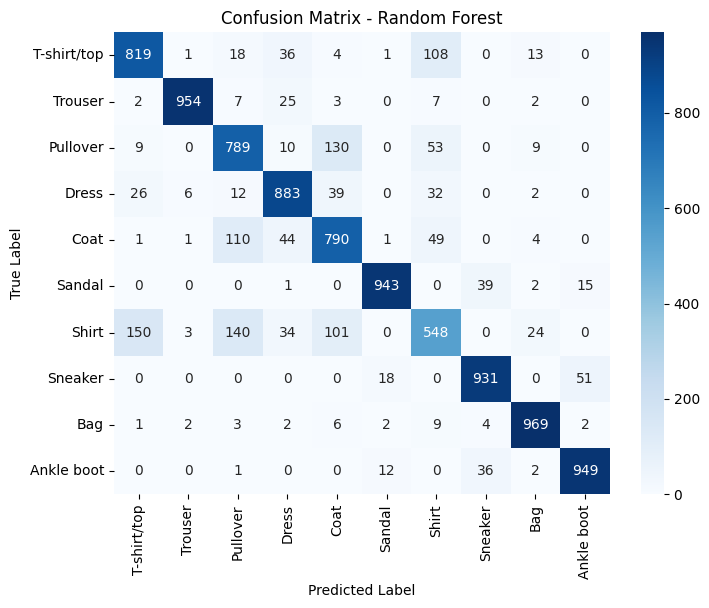

In [ ]:
# -------------------------------------------
# Step 7: Confusion Matrix for Best Model
# -------------------------------------------
best_model = rf_model
y_pred = rf_pred

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
# -------------------------------------------
# Step 8: Classification Report
# -------------------------------------------
print("Classification Report (Random Forest):\n")
print(classification_report(y_test, y_pred, target_names=class_names))

Classification Report (Random Forest):

              precision    recall  f1-score   support

 T-shirt/top       0.81      0.82      0.82      1000
     Trouser       0.99      0.95      0.97      1000
    Pullover       0.73      0.79      0.76      1000
       Dress       0.85      0.88      0.87      1000
        Coat       0.74      0.79      0.76      1000
      Sandal       0.97      0.94      0.95      1000
       Shirt       0.68      0.55      0.61      1000
     Sneaker       0.92      0.93      0.93      1000
         Bag       0.94      0.97      0.96      1000
  Ankle boot       0.93      0.95      0.94      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



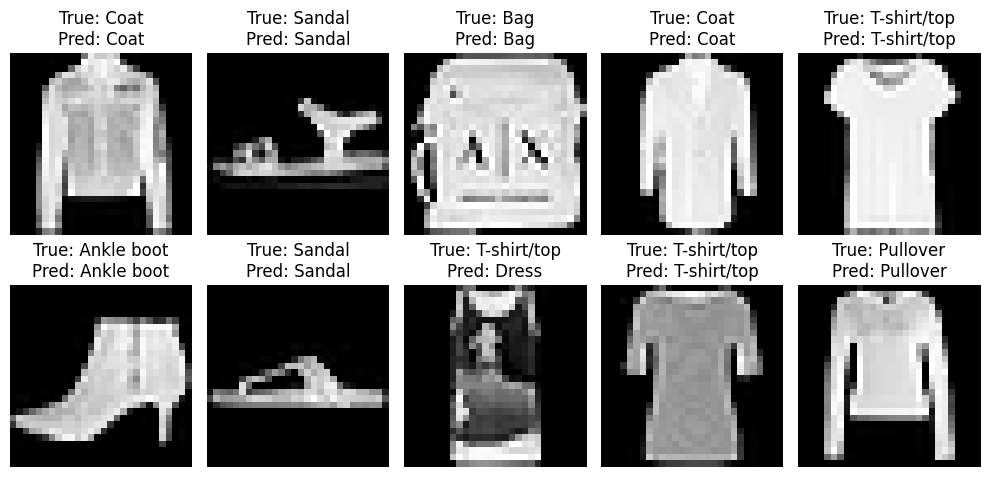

In [ ]:
# -------------------------------------------
# Step 9: Random Predictions Visualization
# -------------------------------------------
plt.figure(figsize=(10,5))
for i in range(10):
    index = np.random.randint(0, len(X_test))
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[index], cmap='gray')
    plt.title(f"True: {class_names[y_test[index]]}\nPred: {class_names[y_pred[index]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()